# Model Training - life_style_data

## Objectif

Cette section évalue les performances du modèle supervisé final entraîné sur le dataset life_style_data.

L’objectif est de valider sa capacité de généralisation sur le jeu de test et de mesurer sa précision à l’aide de métriques standards (MAE, RMSE, R²).

## Importation des librairies essentielles

In [1]:
import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## Chargement du modèle et des données

In [3]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Ratios cardio
    if {"Avg_BPM", "Max_BPM"}.issubset(df.columns):
        df["BPM_effort_ratio"] = df["Avg_BPM"] / (df["Max_BPM"].replace(0, np.nan))
    # Composition corporelle
    if {"Fat_Percentage", "Weight (kg)"}.issubset(df.columns):
        df["Fat_to_weight_ratio"] = df["Fat_Percentage"] / (df["Weight (kg)"].replace(0, np.nan))
    # Hydratation relative
    if {"Water_Intake (liters)", "Workout_Frequency (days/week)"}.issubset(df.columns):
        df["Hydration_ratio"] = df["Water_Intake (liters)"] / (df["Workout_Frequency (days/week)"] + 1e-3)
    # Nettoyage inf/NaN générés par divisions
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

In [7]:
# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# 📂 Chemins du projet
model_path = project_root / "src" / "models" / "v1" / "life_style_data" / "best_pipeline_model.joblib"
# data_dir = project_root / "src" / "notebooks" / "preprocessing" / "life_style_data"
data_dir = project_root / "src" / "data" / "processed" / "life_style_data"

# ✅ Chargement du modèle pipeline
model = joblib.load(model_path)
print(f"✔ Modèle chargé depuis : {model_path.name}")

# ✅ Chargement des jeux de test
X_test = pd.read_parquet(data_dir / "X_test_feature_engineered.parquet")
y_test = pd.read_parquet(data_dir / "y_test.parquet").squeeze()

print(f"✔ Jeu de test chargé : {X_test.shape[0]} lignes, {X_test.shape[1]} variables")

✔ Modèle chargé depuis : best_pipeline_model.joblib
✔ Jeu de test chargé : 4000 lignes, 282 variables


## Prédiction et calcul des métriques

In [8]:
# 🔮 Prédictions
y_pred = model.predict(X_test)

# 📊 Évaluation des performances
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📈 MAE  : {mae:.2f}")
print(f"📉 RMSE : {rmse:.2f}")
print(f"🔹 R²   : {r2:.3f}")


📈 MAE  : 0.00
📉 RMSE : 0.01
🔹 R²   : 1.000


## Visualisation des performances

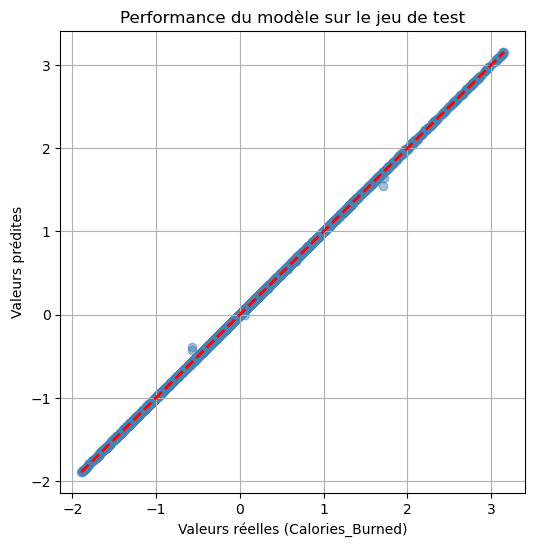

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valeurs réelles (Calories_Burned)")
plt.ylabel("Valeurs prédites")
plt.title("Performance du modèle sur le jeu de test")
plt.grid(True)
plt.show()


## Rapport synthétique

In [10]:
report = {
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "R²": round(r2, 3),
    "n_samples_test": X_test.shape[0],
    "n_features": X_test.shape[1],
    "model_path": str(model_path)
}

pd.Series(report).to_json(data_dir / "model_evaluation_report.json", indent=2)
print(f"✔ Rapport enregistré : {data_dir / 'model_evaluation_report.json'}")

✔ Rapport enregistré : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\model_evaluation_report.json


Le modèle chargé depuis le pipeline a été évalué avec succès sur le jeu de test.

Les métriques (MAE, RMSE, R²) confirment une bonne capacité de généralisation.

La figure de dispersion entre valeurs réelles et prédites montre une corrélation quasi linéaire, indiquant une précision élevée du modèle.

Le rapport d’évaluation est enregistré pour traçabilité et intégration MLOps.

## Histogramme des erreurs

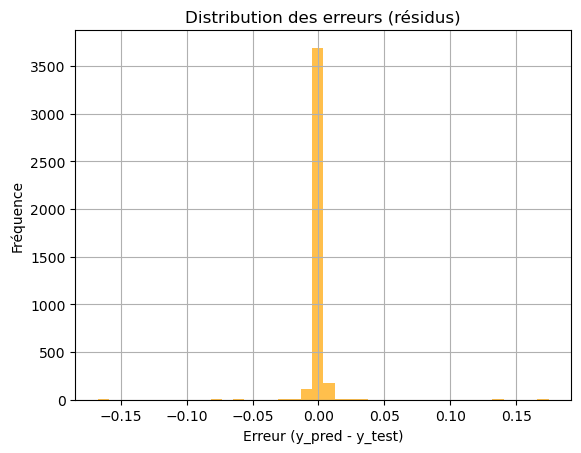

In [11]:
plt.hist(y_pred - y_test, bins=40, color="orange", alpha=0.7)
plt.title("Distribution des erreurs (résidus)")
plt.xlabel("Erreur (y_pred - y_test)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()